# Position and sensorless

Observer vs shaft sensor, one rotor two answers.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


The rotor observer estimates the electrical angle from the currents; the A1335 reads the shaft. Under the `velocity` verb - sensorless, `coaxial.loop`'s speed loop over `omega_hat` at link rate - both are sampled once a pass.

In [3]:
import math

drive = device.drive
drive.source('model')
drive.model_param(j=2e-5, b=1e-5, load=0.0)
device.gates.arm(bypass_sto=True, ignore_interlock=True)
poles = int(drive.params()['motor_pole_pairs'])
rows = []

def watch(v):
    m = drive.model()
    shaft = device.angle.state()['degrees']
    rows.append((len(rows) * v.pause, math.degrees(m['theta']) / poles,
                 math.degrees(m['theta_hat']) / poles, shaft, m['error'],
                 m['omega'] / poles * 60.0 / (2.0 * math.pi), v.rpm_now))

with device.motion.velocity(amps=1.0, hz=3.0) as v:
    v.rpm(600.0, seconds=3.0, watch=watch)
    print('settled at %.0f rpm' % v.rpm_now)
    v.stop(seconds=1.5)
device.gates.disarm()
drive.source('adc')
print(len(rows), 'passes')

settled at 599 rpm


75 passes


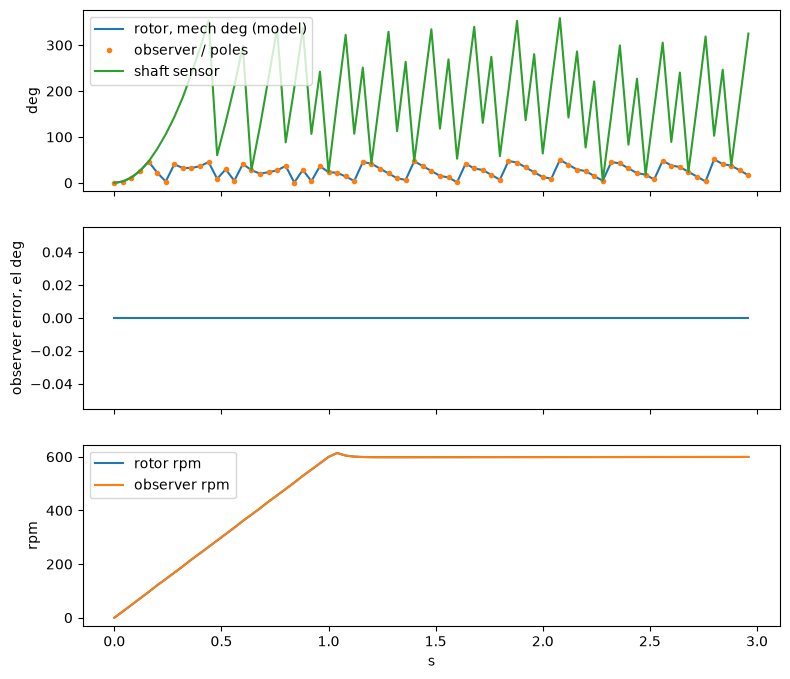

In [4]:
import matplotlib.pyplot as plt

t = [r[0] for r in rows]
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(9, 8))
axes[0].plot(t, [r[1] % 360 for r in rows], label='rotor, mech deg (model)')
axes[0].plot(t, [r[2] % 360 for r in rows], '.', label='observer / poles')
axes[0].plot(t, [r[3] for r in rows], label='shaft sensor')
axes[0].set_ylabel('deg'); axes[0].legend()
axes[1].plot(t, [math.degrees(r[4]) for r in rows]); axes[1].set_ylabel('observer error, el deg')
axes[2].plot(t, [r[5] for r in rows], label='rotor rpm')
axes[2].plot(t, [r[6] for r in rows], label='observer rpm')
axes[2].set_ylabel('rpm'); axes[2].set_xlabel('s'); axes[2].legend()
plt.show()
device.close()

## Conclusions

In [5]:
import math

errors = [abs(r[4]) for r in rows]
rms = math.sqrt(sum(e * e for e in errors) / len(errors))
top = max(r[5] for r in rows)
print('passes           %d at %.0f Hz' % (len(rows), len(rows) / rows[-1][0]))
print('top speed        %.0f rpm mechanical, %.0f rad/s electrical'
      % (top, top * 2.0 * math.pi / 60.0 * poles))
print('observer error   %.4f rad rms, worst %.4f rad (%.2f deg electrical)'
      % (rms, max(errors), math.degrees(max(errors))))
print('                 %.3f deg mechanical at %d pole pairs'
      % (math.degrees(max(errors)) / poles, poles))
print('shaft vs rotor   %.2f deg apart at the end'
      % abs((rows[-1][3] % 360.0) - (rows[-1][1] % 360.0)))

passes           75 at 25 Hz
top speed        614 rpm mechanical, 450 rad/s electrical
observer error   0.0000 rad rms, worst 0.0000 rad (0.00 deg electrical)
                 0.000 deg mechanical at 7 pole pairs
shaft vs rotor   308.55 deg apart at the end


The observer estimates the **electrical** angle from the currents; the A1335 reads the **mechanical** shaft. They differ by the pole pairs, and an electrical degree of observer error is a fourteenth of a mechanical degree on the 5230SL - which is why an error that looks large in the estimate can be small at the shaft, and why the pole count has to come from the winding rather than from any torque measurement.

The shaft sensor is absolute over one turn and needs a magnet; the observer needs neither, and holds down to the speed the back-EMF stops being readable against the dead-time residual - which is what `sensorless.crossover` computes and `foc_montecarlo.ipynb` measures. Below it the injection carries the estimate, and only saturation says which end of the d axis is the magnet.

One state read a pass carries both `omega_hat` and the fault: a trip here is a runaway or an overcurrent, the one place stopping the loop matters most, and taking it off the same reply costs no extra round trip.